# **Intro to Graph Theory - Colab 01. **

NetworkX is one of the most frequently used Python packages to create, manipulate, and mine graphs.

With NetworkX you can load and store networks in standard and nonstandard data formats, generate many types of random and classic networks, analyze network structure, build network models, design new network algorithms, draw networks, and much more.

Library documentation: <a>https://networkx.org/documentation/stable/</a> .

**Please make a copy before you proceed.**

# Setup

In [2]:
# Import the NetworkX package and some other may-be-useful packages
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Graph

In [3]:
# Create an undirected graph G
G = nx.Graph()
print(G.is_directed())

False


In [4]:
# add one node
G.add_node(1)

# add a group of nodes at once
G.add_nodes_from([2, 3, 4])

In [5]:
# add edges using similar methods
G.add_edge(1, 2)
e = (2, 3)
G.add_edge(*e)
G.add_edges_from([(2, 4), (3, 4), (1, 4)])

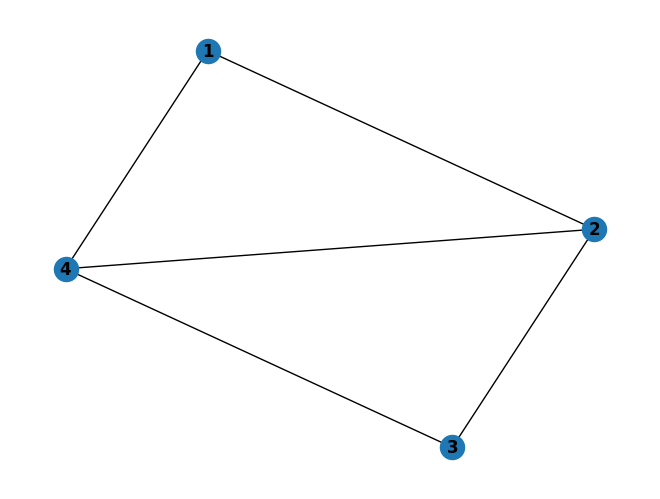

In [6]:
# draw the graph
nx.draw(G, with_labels=True, font_weight='bold')

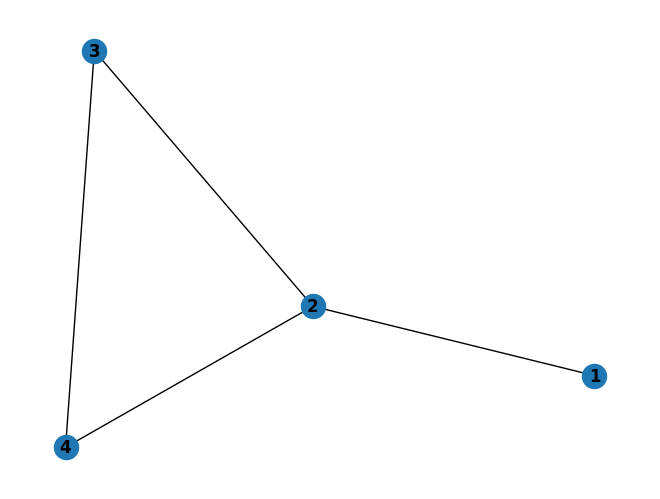

In [7]:
# remove an edge
G.remove_edge(1, 4)

# and then draw the new graph
nx.draw(G, with_labels=True, font_weight='bold')

In [8]:
# Create  a directed graph H from a list of edges
edgelist = [(0, 1), (1, 2), (1, 3), (2, 3), (3, 1)]
H = nx.DiGraph(edgelist)

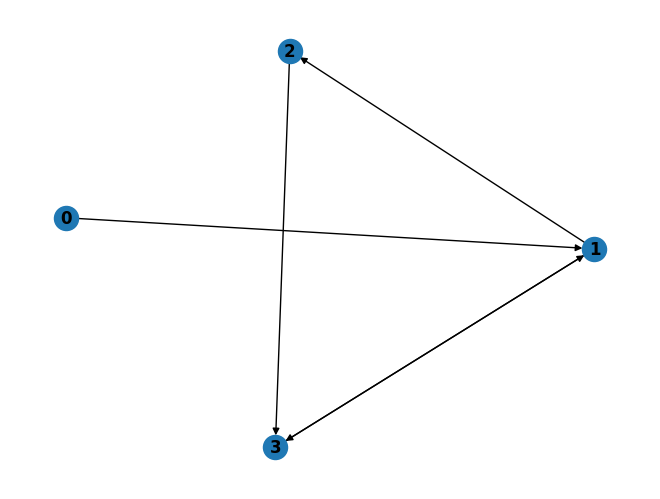

In [9]:
nx.draw(H, with_labels=True, font_weight='bold')

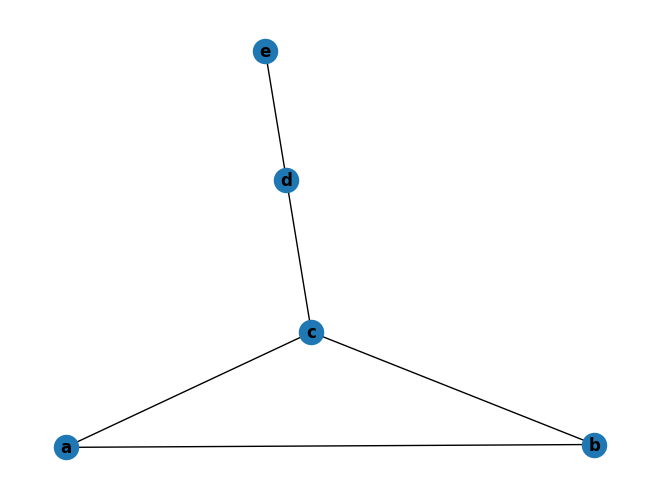

In [10]:
# create a graph using adjacency lists with nodes 'names'
adjacency_dict = {'a': ('b', 'c'), 'b': ('a', 'c'), 'c': ('a', 'b', 'd'), 'd': ('e') }
F = nx.Graph(adjacency_dict)
nx.draw(F, with_labels=True, font_weight='bold')

In [11]:
# number of nodes
G.number_of_nodes()

4

In [12]:
# number of edges
F.number_of_edges()

5

In [13]:
# List all of the nodes
nd_list = list(G.nodes)
print('List of the graph nodes:', nd_list)

# List all of the edges
edg_list = list(G.edges)
print('List of the graph edges', edg_list)

# List of the nodes incident to the node 3
adj_list = list(G.adj[3])
print('Nodes incident to the node 3:', adj_list)

List of the graph nodes: [1, 2, 3, 4]
List of the graph edges [(1, 2), (2, 3), (2, 4), (3, 4)]
Nodes incident to the node 3: [2, 4]


In [14]:
# degree of a node
G.degree(3)

2

In [15]:
# Returns True if the graph is connected, False otherwise.
nx.is_connected(G)

True

In [16]:
# List of all connected components
components = list(nx.connected_components(G))

print(f'The number of conneted component: {len(components)}')
print(f'List of all connected components: {components}')

The number of conneted component: 1
List of all connected components: [{1, 2, 3, 4}]


# Connectedness in digraphs

There are two notions of connectedness in directed graphs, depending on whether the directions
of the edges are considered.
* A directed graph is *strongly connected* if there is a path from $u$ to $v$ and from $v$ to $u$ whenever $u$ and $b$ are vertices in the graph.
* A directed graph is *weakly connected* if there is a path between every two vertices in the underlying undirected graph.






Are the directed graphs $G$ and $H$ strongly connected? Are they weakly connected?

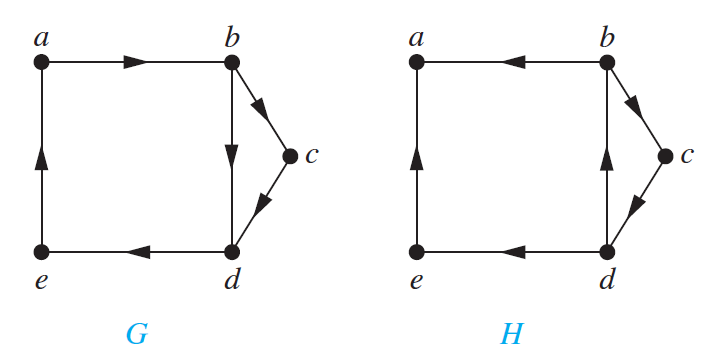

**Strongly connected components**
* The subgraphs of a directed graph $G$ that are strongly connected but not contained in larger strongly connected subgraphs are called the *strongly connected components* or strong components of $G$.
* If $u$ and $v$ are two vertices in a directed graph, their strong
components are either the same or disjoint.

Determine whether each of  graphs from a picture above is strongly connected
and if not, whether it is weakly connected. Find the strongly connected components of each of these graphs.

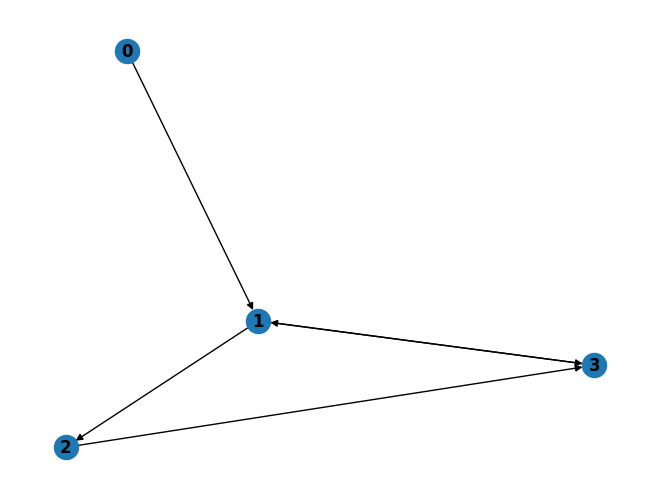

In [17]:
nx.draw(H, with_labels=True, font_weight='bold')

In [18]:
# H is a weakly connected graph
nx.is_weakly_connected(H)

True

In [19]:
# H is not a strongly connected graph
nx.is_strongly_connected(H)

False

In [20]:
# Returns number of strongly connected components in graph.
nx.number_strongly_connected_components(H)

2

In [21]:
# Generate nodes in strongly connected components of graph.
scc_H = list(nx.strongly_connected_components(H))

print(f'List of all connected components: {scc_H}')

List of all connected components: [{1, 2, 3}, {0}]


# Exercise 1.


1.   Create an undirected graph from a list of edges $E = \{(a,b),  (a,d), (b,c), (c,a), (c,e), (d,c)\}$.
  * Draw the graph;
  * Add a new node $f$ and connect the new node with nodes $a$ and $d$;
  * Draw the graph again;
  * Print  lists of neighbors of nodes $a$ and $c$.

2.  Create a directed graph from a list of edges $E = \{(a,b),  (b,c), (c,a), (c,e), (d,c)\}$.
  * Find nodes incident to nodes $a$; $c$.
  * Add edges to the graph so that the new graph has two strongly connected components; one component of strong connectivity.
  * Check your results.



In [19]:
edgelist_Q = [('a', 'b'), ('b', 'c'), ('c', 'a'), ('c', 'e'), ('d', 'c')]
Q = nx.DiGraph(edgelist_Q)

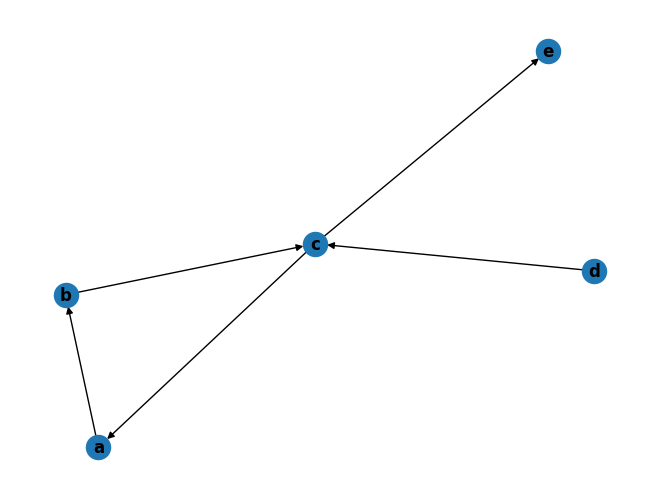

In [20]:
nx.draw(Q, with_labels=True, font_weight='bold')

Nodes incident to node a: ['b', 'c']
Nodes incident to node c: ['a', 'b', 'd', 'e']

Number of strongly connected components: 1
Strongly connected components: [{'c', 'e', 'a', 'd', 'b'}]


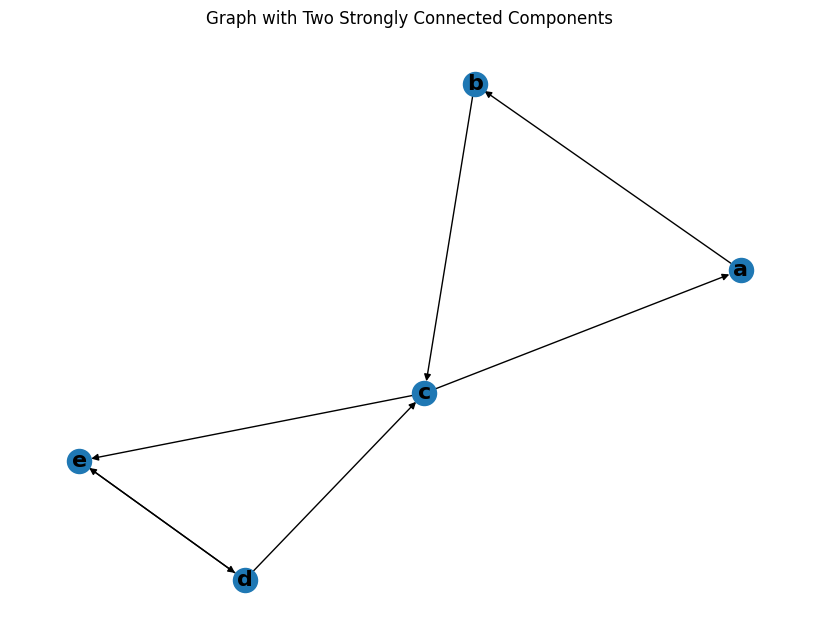

In [ ]:
# Find nodes incident to node a (incoming and outgoing)
incident_to_a = list(Q.predecessors('a')) + list(Q.successors('a'))
print(f"Nodes incident to node a: {sorted(set(incident_to_a))}")

# Find nodes incident to node c
incident_to_c = list(Q.predecessors('c')) + list(Q.successors('c'))
print(f"Nodes incident to node c: {sorted(set(incident_to_c))}")

# Add edges to create second SCC with nodes d and e
Q.add_edge('e', 'd')  # Makes d and e mutually reachable (d->c->e->d forms cycle)
Q.add_edge('d', 'e')  # Ensure strong connectivity between d and e

# Check SCCs
sccs = list(nx.strongly_connected_components(Q))
print(f"\nNumber of strongly connected components: {len(sccs)}")
print(f"Strongly connected components: {sccs}")

# Draw the new graph
plt.figure(figsize=(8, 6))
nx.draw(Q, with_labels=True, font_weight='bold', font_size=16, arrows=True)
plt.title("Graph with Two Strongly Connected Components")
plt.show()

Trial

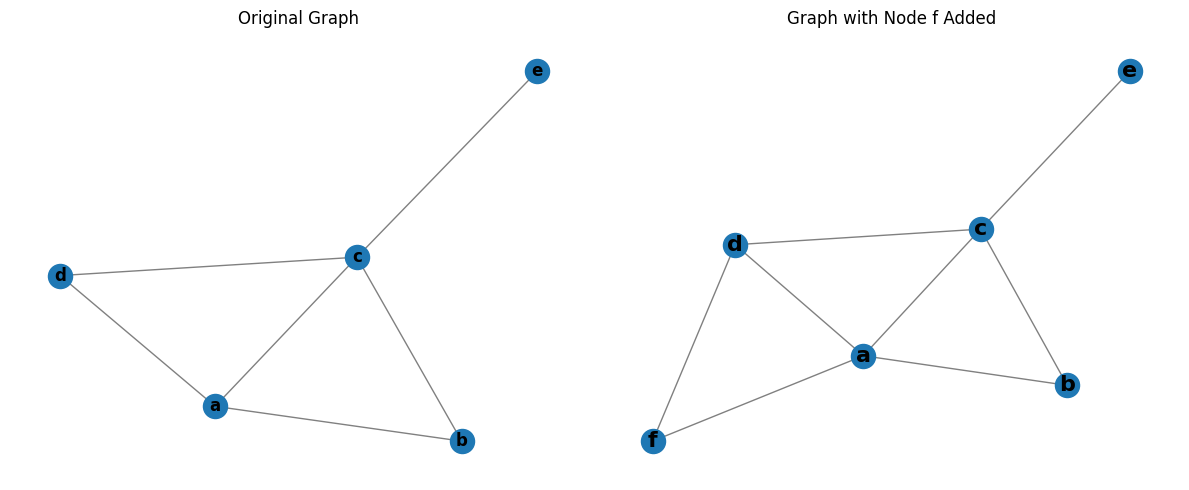

Neighbors of node a: ['b', 'c', 'd', 'f']
Neighbors of node c: ['a', 'b', 'd', 'e']


In [10]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an undirected graph from the list of edges
edges = [('a', 'b'), ('a', 'd'), ('b', 'c'), ('c', 'a'), ('c', 'e'), ('d', 'c')]
G = nx.Graph()
G.add_edges_from(edges)

# Draw the original graph
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
pos = nx.spring_layout(G, seed=42)  # layout for original graph
nx.draw(G, pos, with_labels=True, font_weight='bold', edge_color='gray')
plt.title("Original Graph")

# Add a new node f and connect it with nodes a and d
G.add_node('f')
G.add_edges_from([('f', 'a'), ('f', 'd')])

all_x = [pos[node][0] for node in pos]
all_y = [pos[node][1] for node in pos]
min_x = min(all_x)
min_y = min(all_y)

pos_f = {
    'f': [min_x - 0.3, min_y - 0.3]
}
pos.update(pos_f)

# Draw the graph again using the same positions plus f
plt.subplot(1, 2, 2)
# Draw all nodes except f first
nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes() if n != 'f'])
nx.draw_networkx_nodes(G, pos, nodelist=['f'])
# Draw all edges
nx.draw_networkx_edges(G, pos, edge_color='gray')
# Draw all labels
nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')
plt.title("Graph with Node f Added")
plt.axis('off')

plt.tight_layout()
plt.show()

# Print lists of neighbors of nodes a and c
print(f"Neighbors of node a: {sorted(list(G.neighbors('a')))}")
print(f"Neighbors of node c: {sorted(list(G.neighbors('c')))}")